# Non-Overlapping Window Analysis

This notebook summarizes the q160-update / q300-evaluation comparison across four non-overlapping windows. Comparisons are paired by timestamp and random seed whenever both filters are available.

Positive predictive-score differences favor Rough-SABR. Negative price-error differences favor Rough-SABR.

In [12]:
from pathlib import Path
from math import erfc, sqrt
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

In [13]:
def find_project_root(start=None):
    here = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and notebooks/.")


def project_relative(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

RUN_ROOT = OUTPUTS_DIR / "nonoverlap_q160_eval300"
COMMON_EVAL_ROOT = OUTPUTS_DIR / "common_eval_q160_eval300"
COMPARISON_DIR = RUN_ROOT / "_comparison"
TABLE_DIR = COMPARISON_DIR / "tables"
FIGURE_DIR = COMPARISON_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

WINDOWS = [
    {"key": "w0_400", "label": "0-399", "source": COMMON_EVAL_ROOT},
    {"key": "w401_800", "label": "400-799", "source": RUN_ROOT / "w401_800"},
    {"key": "w801_1200", "label": "800-1199", "source": RUN_ROOT / "w801_1200"},
    {"key": "w1201_1600", "label": "1200-1599", "source": RUN_ROOT / "w1201_1600"},
]
WINDOW_ORDER = [w["key"] for w in WINDOWS]
WINDOW_LABELS = {w["key"]: w["label"] for w in WINDOWS}
WINDOW_RUN_SOURCES = {w["key"]: w["source"] for w in WINDOWS}
MODEL_ORDER = ["Markovian", "Rough-SABR"]
MODEL_LABEL_MAP = {
    "Normal": "Markovian",
    "Markovian SABR": "Markovian",
    "Rough": "Rough-SABR",
}
HAC_LAG = 5


def normalize_model_labels(df):
    if "model" in df.columns:
        df["model"] = df["model"].replace(MODEL_LABEL_MAP)
    return df

## Predictive Score

For each timestamp and seed, the main comparison is the Rough-SABR score minus the Markovian SABR score on the common q300 evaluation panel. The window-level inference uses the seed-averaged timestamp series with a Newey-West HAC standard error.

In [14]:
def parse_run_dir(run_dir: Path):
    name = run_dir.name
    lower = name.lower()
    if lower.startswith("rough"):
        model = "Rough-SABR"
    elif lower.startswith("normal"):
        model = "Markovian"
    else:
        return None

    match = re.search(r"seed(\d+)$", name)
    if match is None:
        return None
    return model, int(match.group(1))


def discover_runs():
    rows = []
    for window, source_dir in WINDOW_RUN_SOURCES.items():
        if not source_dir.exists():
            continue
        for run_dir in sorted(source_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            parsed = parse_run_dir(run_dir)
            if parsed is None:
                continue
            model, seed = parsed
            rows.append(
                {
                    "window": window,
                    "model": model,
                    "seed": seed,
                    "run_dir": run_dir,
                    "has_summary_eval": (run_dir / "model_comparison_summary_eval.csv").exists(),
                    "has_scores_eval": (run_dir / "predictive_loglikelihood_eval.csv").exists(),
                    "has_prices_eval": (run_dir / "predictive_option_prices_eval.csv").exists(),
                    "has_state_path": (run_dir / "filtered_state_path.csv").exists(),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        sources = ", ".join(str(project_relative(p)) for p in WINDOW_RUN_SOURCES.values())
        raise FileNotFoundError(f"No non-overlap runs found under: {sources}")

    out["window"] = pd.Categorical(out["window"], categories=WINDOW_ORDER, ordered=True)
    out["model"] = pd.Categorical(out["model"], categories=MODEL_ORDER, ordered=True)
    return out.sort_values(["window", "model", "seed"]).reset_index(drop=True)


def newey_west_mean_test(values, max_lag=5):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return pd.Series(
            {
                "n_timestamps": n,
                "mean_delta": np.nan,
                "hac_se": np.nan,
                "t_stat": np.nan,
                "p_value": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
            }
        )

    mean = x.mean()
    y = x - mean
    lag = min(int(max_lag), n - 1)
    gamma0 = np.dot(y, y) / n
    long_run_var = gamma0
    for ell in range(1, lag + 1):
        weight = 1.0 - ell / (lag + 1.0)
        gamma = np.dot(y[ell:], y[:-ell]) / n
        long_run_var += 2.0 * weight * gamma

    hac_se = sqrt(max(long_run_var, 0.0) / n)
    t_stat = mean / hac_se if hac_se > 0 else np.nan
    p_value = erfc(abs(float(t_stat)) / sqrt(2.0)) if np.isfinite(t_stat) else np.nan
    return pd.Series(
        {
            "n_timestamps": n,
            "mean_delta": mean,
            "hac_se": hac_se,
            "t_stat": t_stat,
            "p_value": p_value,
            "ci_low": mean - 1.96 * hac_se,
            "ci_high": mean + 1.96 * hac_se,
        }
    )


def one_sided_pvalue_greater(t_stat):
    if not np.isfinite(t_stat):
        return np.nan
    return 0.5 * erfc(float(t_stat) / sqrt(2.0))


def format_ci(low, high, digits=4):
    if pd.isna(low) or pd.isna(high):
        return ""
    return f"[{low:.{digits}f}, {high:.{digits}f}]"

## Run Inventory

The first window uses the common-evaluation runs. The remaining windows use the non-overlapping-window runs.

In [15]:
inventory = discover_runs()
inventory_display = (
    inventory.groupby(["window", "model"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        seeds=("seed", lambda s: ", ".join(str(int(x)) for x in sorted(s.unique()))),
        summaries_available=("has_summary_eval", "sum"),
        score_files_available=("has_scores_eval", "sum"),
        price_files_available=("has_prices_eval", "sum"),
    )
    .reset_index()
)
inventory_display["window"] = inventory_display["window"].astype(str).map(WINDOW_LABELS)
inventory_display.to_csv(TABLE_DIR / "nonoverlap_run_inventory.csv", index=False)
display(inventory_display)

,window,model,n_seeds,seeds,summaries_available,score_files_available,price_files_available
0,0-399,Markovian,5,"123, 456, 789, 101112, 131415",5,5,5
1,0-399,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5
2,400-799,Markovian,5,"123, 456, 789, 101112, 131415",5,5,5
3,400-799,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5
4,800-1199,Markovian,5,"123, 456, 789, 101112, 131415",5,5,5
5,800-1199,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5
6,1200-1599,Markovian,5,"123, 456, 789, 101112, 131415",5,5,5
7,1200-1599,Rough-SABR,5,"123, 456, 789, 101112, 131415",5,5,5


## Score Summaries

These tables summarize the q300 predictive scores by window, model, and seed.

In [16]:
summary_rows = []
for row in inventory.itertuples(index=False):
    path = row.run_dir / "model_comparison_summary_eval.csv"
    if not path.exists():
        continue
    summary = pd.read_csv(path).iloc[0].to_dict()
    summary.update({"window": row.window, "model": row.model, "seed": row.seed})
    summary_rows.append(summary)

if not summary_rows:
    raise FileNotFoundError("No model_comparison_summary_eval.csv files were found.")

summary_eval = pd.DataFrame(summary_rows)
summary_eval["runtime_minutes"] = summary_eval["total_runtime_seconds"] / 60.0
summary_eval["window"] = pd.Categorical(summary_eval["window"], categories=WINDOW_ORDER, ordered=True)
summary_eval = normalize_model_labels(summary_eval)
summary_eval["model"] = pd.Categorical(summary_eval["model"], categories=MODEL_ORDER, ordered=True)
summary_eval = summary_eval.sort_values(["window", "model", "seed"]).reset_index(drop=True)

seed_summary_cols = [
    "window",
    "model",
    "seed",
    "n_timestamps",
    "n_quotes_total",
    "total_log_predictive_likelihood",
    "mean_timestamp_log_predictive_likelihood",
    "avg_log_predictive_likelihood_per_quote",
    "mean_ess",
    "min_ess",
    "runtime_minutes",
]
summary_eval[seed_summary_cols].to_csv(TABLE_DIR / "nonoverlap_seed_level_summary_eval.csv", index=False)

window_model_summary = (
    summary_eval.groupby(["window", "model"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        n_timestamps=("n_timestamps", "mean"),
        n_quotes_total=("n_quotes_total", "mean"),
        mean_timestamp_score=("mean_timestamp_log_predictive_likelihood", "mean"),
        mean_score_per_quote=("avg_log_predictive_likelihood_per_quote", "mean"),
        mean_ess=("mean_ess", "mean"),
        min_ess=("min_ess", "min"),
        runtime_minutes=("runtime_minutes", "mean"),
    )
    .reset_index()
)
window_model_summary["window"] = window_model_summary["window"].astype(str).map(WINDOW_LABELS)
window_model_summary.to_csv(TABLE_DIR / "nonoverlap_window_model_summary_eval.csv", index=False)
display(window_model_summary.round(4))

,window,model,n_seeds,n_timestamps,n_quotes_total,mean_timestamp_score,mean_score_per_quote,mean_ess,min_ess,runtime_minutes
0,0-399,Markovian,5,400.0,116008.0,-20.1616,-0.0695,264.6778,210.0047,16.7724
1,0-399,Rough-SABR,5,400.0,116008.0,-19.1412,-0.0660,263.7384,210.0679,81.5777
2,400-799,Markovian,5,400.0,118614.0,-40.1049,-0.1352,263.6318,210.0574,42.7622
3,400-799,Rough-SABR,5,400.0,118614.0,-32.6156,-0.1100,262.8201,210.0138,143.5925
4,800-1199,Markovian,5,400.0,119706.0,-52.9727,-0.1770,261.9465,210.0007,45.7734
5,800-1199,Rough-SABR,5,400.0,119706.0,-46.0201,-0.1538,262.4992,210.0001,155.9125
6,1200-1599,Markovian,5,400.0,119616.0,-37.6966,-0.1261,264.6979,210.0894,47.2856
7,1200-1599,Rough-SABR,5,400.0,119616.0,-34.2462,-0.1145,264.2215,210.0073,120.0694


## Paired Predictive Scores

The paired table merges Rough-SABR and Markovian SABR by window, seed, and timestamp.

In [17]:
score_cols = [
    "capture_time_utc",
    "t_index",
    "n_quotes",
    "n_update_quotes",
    "log_predictive_likelihood",
    "avg_log_predictive_likelihood_per_quote",
    "eval_n_options",
    "eval_n_priced",
]

score_rows = []
for row in inventory.itertuples(index=False):
    path = row.run_dir / "predictive_loglikelihood_eval.csv"
    if not path.exists():
        continue
    df = pd.read_csv(path, usecols=score_cols)
    df["window"] = row.window
    df["model"] = row.model
    df["seed"] = row.seed
    score_rows.append(df)

if not score_rows:
    raise FileNotFoundError("No predictive_loglikelihood_eval.csv files were found.")

scores = pd.concat(score_rows, ignore_index=True)
scores["capture_time_utc"] = pd.to_datetime(scores["capture_time_utc"], utc=True)
scores["invalid_pricing_rate"] = 1.0 - scores["eval_n_priced"] / scores["eval_n_options"]
scores["window"] = pd.Categorical(scores["window"], categories=WINDOW_ORDER, ordered=True)
scores = normalize_model_labels(scores)
scores["model"] = pd.Categorical(scores["model"], categories=MODEL_ORDER, ordered=True)
scores.to_csv(TABLE_DIR / "nonoverlap_timestamp_scores_eval.csv", index=False)

rough = scores[scores["model"] == "Rough-SABR"].copy()
normal = scores[scores["model"] == "Markovian"].copy()
paired_scores = rough.merge(
    normal,
    on=["window", "seed", "t_index"],
    suffixes=("_rough", "_normal"),
)
paired_scores["delta_log_score"] = (
    paired_scores["log_predictive_likelihood_rough"]
    - paired_scores["log_predictive_likelihood_normal"]
)
paired_scores["delta_avg_score_per_quote"] = (
    paired_scores["avg_log_predictive_likelihood_per_quote_rough"]
    - paired_scores["avg_log_predictive_likelihood_per_quote_normal"]
)

seed_avg_delta = (
    paired_scores.groupby(["window", "t_index"], observed=True)
    .agg(
        capture_time_utc=("capture_time_utc_rough", "first"),
        n_seeds=("seed", "nunique"),
        delta_log_score=("delta_log_score", "mean"),
        delta_avg_score_per_quote=("delta_avg_score_per_quote", "mean"),
        normal_score=("log_predictive_likelihood_normal", "mean"),
        rough_score=("log_predictive_likelihood_rough", "mean"),
    )
    .reset_index()
)

paired_scores.to_csv(TABLE_DIR / "nonoverlap_paired_scores_by_seed_timestamp.csv", index=False)
seed_avg_delta.to_csv(TABLE_DIR / "nonoverlap_seed_averaged_timestamp_deltas.csv", index=False)

score_count_summary = (
    paired_scores.groupby("window", observed=True)
    .agg(
        paired_timestamp_seed_obs=("t_index", "size"),
        timestamps=("t_index", "nunique"),
        seeds=("seed", "nunique"),
    )
    .reset_index()
)
score_count_summary["window"] = score_count_summary["window"].astype(str).map(WINDOW_LABELS)
display(score_count_summary)

,window,paired_timestamp_seed_obs,timestamps,seeds
0,0-399,2000,400,5
1,400-799,2000,400,5
2,800-1199,2000,400,5
3,1200-1599,2000,400,5


## Main Predictive-Score Inference

Positive differences mean the Rough-SABR filter assigned the higher predictive score.

In [18]:
def build_main_inference_row(window_label, df):
    test = newey_west_mean_test(df["delta_log_score"], max_lag=HAC_LAG)
    rough_wins = int((df["delta_log_score"] > 0).sum())
    n_timestamps = int(len(df))
    return {
        "Window": window_label,
        "Timestamps": n_timestamps,
        "Seeds": int(df["n_seeds"].min()) if n_timestamps else 0,
        "Mean Rough - Markovian": test["mean_delta"],
        "Median Rough - Markovian": df["delta_log_score"].median(),
        "Rough wins count": rough_wins,
        "Rough wins pct": rough_wins / n_timestamps if n_timestamps else np.nan,
        "HAC SE": test["hac_se"],
        "HAC CI low": test["ci_low"],
        "HAC CI high": test["ci_high"],
        "HAC t-stat": test["t_stat"],
        "One-sided HAC p-value": one_sided_pvalue_greater(test["t_stat"]),
    }


main_inference_rows = []
for window in WINDOW_ORDER:
    d = seed_avg_delta[seed_avg_delta["window"] == window].sort_values("t_index")
    if d.empty:
        continue
    main_inference_rows.append(build_main_inference_row(WINDOW_LABELS.get(window, window), d))

all_windows_delta = seed_avg_delta.sort_values(["window", "t_index"])
main_inference_rows.append(build_main_inference_row("All windows", all_windows_delta))

main_predictive_inference = pd.DataFrame(main_inference_rows)
main_predictive_inference.to_csv(TABLE_DIR / "nonoverlap_main_predictive_inference_table_numeric.csv", index=False)

main_predictive_inference_display = main_predictive_inference.copy()
main_predictive_inference_display["Rough wins"] = main_predictive_inference_display.apply(
    lambda r: f"{int(r['Rough wins count'])} / {int(r['Timestamps'])} ({100 * r['Rough wins pct']:.2f}%)",
    axis=1,
)
main_predictive_inference_display["HAC 95% CI"] = main_predictive_inference_display.apply(
    lambda r: format_ci(r["HAC CI low"], r["HAC CI high"], digits=4),
    axis=1,
)
main_predictive_inference_display["One-sided HAC p-value"] = main_predictive_inference_display[
    "One-sided HAC p-value"
].map(lambda p: "< 0.001" if pd.notna(p) and p < 0.001 else f"{p:.4f}" if pd.notna(p) else "")

main_predictive_inference_display = main_predictive_inference_display[
    [
        "Window",
        "Timestamps",
        "Seeds",
        "Mean Rough - Markovian",
        "Median Rough - Markovian",
        "Rough wins",
        "HAC SE",
        "HAC 95% CI",
        "One-sided HAC p-value",
    ]
]
main_predictive_inference_display.to_csv(TABLE_DIR / "nonoverlap_main_predictive_inference_table_display.csv", index=False)
display(main_predictive_inference_display.round({"Mean Rough - Markovian": 4, "Median Rough - Markovian": 4, "HAC SE": 4}))

,Window,Timestamps,Seeds,Mean Rough - Markovian,Median Rough - Markovian,Rough wins,HAC SE,HAC 95% CI,One-sided HAC p-value
0,0-399,400,5,1.0204,0.9871,365 / 400 (91.25%),0.0602,"[0.9024, 1.1384]",< 0.001
1,400-799,400,5,7.4893,7.3746,399 / 400 (99.75%),0.2525,"[6.9944, 7.9842]",< 0.001
2,800-1199,400,5,6.9525,6.7632,391 / 400 (97.75%),0.2886,"[6.3868, 7.5183]",< 0.001
3,1200-1599,400,5,3.4504,2.7210,364 / 400 (91.00%),0.3617,"[2.7415, 4.1593]",< 0.001
4,All windows,1600,5,4.7281,4.0096,1519 / 1600 (94.94%),0.2093,"[4.3180, 5.1383]",< 0.001


## Predictive-Score Difference Plot

This is the main non-overlapping-window figure for the predictive-score comparison.

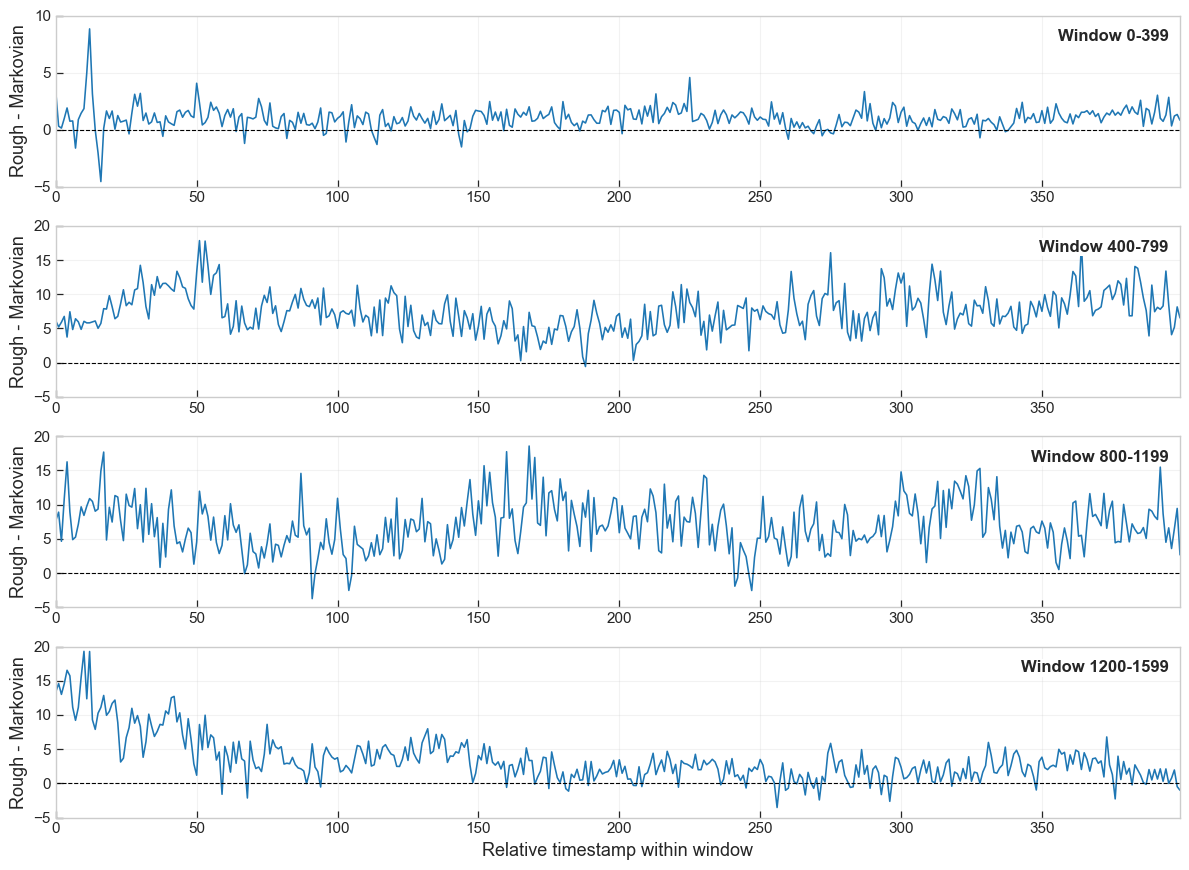

In [19]:
fig, axes = plt.subplots(len(WINDOW_ORDER), 1, figsize=(12, 2.2 * len(WINDOW_ORDER)), sharex=False)
if len(WINDOW_ORDER) == 1:
    axes = [axes]

for ax, window in zip(axes, WINDOW_ORDER):
    d = seed_avg_delta[seed_avg_delta["window"] == window].sort_values("t_index")
    if d.empty:
        ax.set_visible(False)
        continue

    x = np.arange(len(d))
    ax.plot(x, d["delta_log_score"], color="#1f77b4", linewidth=1.15)
    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.text(
        0.99,
        0.92,
        f"Window {WINDOW_LABELS.get(window, window)}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12,
        fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
    )
    ax.set_xlim(0, max(len(d) - 1, 1))
    ymin = 5 * np.floor(min(0.0, d["delta_log_score"].min()) / 5)
    ymax = 5 * np.ceil(max(0.0, d["delta_log_score"].max()) / 5)
    if ymax <= ymin:
        ymax = ymin + 5
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Rough - Markovian", fontsize=13)
    ax.tick_params(axis="both", which="major", direction="in", labelsize=11, length=5, width=0.9)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Relative timestamp within window", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nonoverlap_timestamp_score_differences.png", dpi=200, bbox_inches="tight")
plt.show()

## Quote-Set and Pricing Audit

These tables check that the model comparison uses matching quote panels and records invalid-pricing counts.

In [20]:
quote_audit_source = (
    scores.sort_values(["window", "seed", "t_index", "model"])
    .drop_duplicates(["window", "seed", "t_index"])
    .copy()
)

quote_set_audit = (
    quote_audit_source.groupby("window", observed=True)
    .agg(
        Timestamps=("t_index", "nunique"),
        Seeds=("seed", "nunique"),
        **{
            "Mean update quotes": ("n_update_quotes", "mean"),
            "Mean eval quotes": ("eval_n_options", "mean"),
            "Min eval quotes": ("eval_n_options", "min"),
            "Max eval quotes": ("eval_n_options", "max"),
            "Total eval quote-seed obs.": ("eval_n_options", "sum"),
        },
    )
    .reset_index()
)

all_windows_row = pd.DataFrame(
    [
        {
            "window": "All windows",
            "Timestamps": quote_set_audit["Timestamps"].sum(),
            "Seeds": quote_audit_source["seed"].nunique(),
            "Mean update quotes": quote_audit_source["n_update_quotes"].mean(),
            "Mean eval quotes": quote_audit_source["eval_n_options"].mean(),
            "Min eval quotes": quote_audit_source["eval_n_options"].min(),
            "Max eval quotes": quote_audit_source["eval_n_options"].max(),
            "Total eval quote-seed obs.": quote_audit_source["eval_n_options"].sum(),
        }
    ]
)
quote_set_audit = pd.concat([quote_set_audit, all_windows_row], ignore_index=True)
quote_set_audit["Window"] = quote_set_audit["window"].astype(str).map(WINDOW_LABELS).fillna(quote_set_audit["window"].astype(str))
quote_set_audit = quote_set_audit[
    [
        "Window",
        "Timestamps",
        "Seeds",
        "Mean update quotes",
        "Mean eval quotes",
        "Min eval quotes",
        "Max eval quotes",
        "Total eval quote-seed obs.",
    ]
]
int_cols = ["Timestamps", "Seeds", "Min eval quotes", "Max eval quotes", "Total eval quote-seed obs."]
quote_set_audit[int_cols] = quote_set_audit[int_cols].round().astype(int)
quote_set_audit.to_csv(TABLE_DIR / "nonoverlap_quote_set_audit_table.csv", index=False)

wide_quotes = scores.pivot_table(
    index=["window", "seed", "t_index"],
    columns="model",
    values=["n_quotes", "n_update_quotes", "eval_n_options", "eval_n_priced", "invalid_pricing_rate"],
    observed=True,
)
wide_quotes.columns = [f"{a}_{b}" for a, b in wide_quotes.columns]
wide_quotes = wide_quotes.reset_index()

for col in ["n_quotes", "n_update_quotes", "eval_n_options", "eval_n_priced"]:
    wide_quotes[f"{col}_diff_rough_minus_normal"] = wide_quotes[f"{col}_Rough-SABR"] - wide_quotes[f"{col}_Markovian"]

comparability = (
    wide_quotes.groupby("window", observed=True)
    .agg(
        n_paired_timestamp_seed=("t_index", "size"),
        max_abs_eval_quote_count_diff=("n_quotes_diff_rough_minus_normal", lambda x: np.abs(x).max()),
        max_abs_update_quote_count_diff=("n_update_quotes_diff_rough_minus_normal", lambda x: np.abs(x).max()),
        mean_invalid_rate_normal=("invalid_pricing_rate_Markovian", "mean"),
        mean_invalid_rate_rough=("invalid_pricing_rate_Rough-SABR", "mean"),
        max_invalid_rate_normal=("invalid_pricing_rate_Markovian", "max"),
        max_invalid_rate_rough=("invalid_pricing_rate_Rough-SABR", "max"),
    )
    .reset_index()
)
comparability["window"] = comparability["window"].astype(str).map(WINDOW_LABELS)
comparability.to_csv(TABLE_DIR / "nonoverlap_quote_comparability_and_invalid_rates.csv", index=False)

invalid_pricing_by_window = scores.copy()
invalid_pricing_by_window["invalid_pricings"] = invalid_pricing_by_window["eval_n_options"] - invalid_pricing_by_window["eval_n_priced"]
invalid_pricing_table = (
    invalid_pricing_by_window.groupby(["window", "model"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        timestamp_seed_observations=("t_index", "size"),
        evaluation_quotes=("eval_n_options", "sum"),
        successfully_priced_quotes=("eval_n_priced", "sum"),
        invalid_pricings=("invalid_pricings", "sum"),
    )
    .reset_index()
)
invalid_pricing_table["invalid_rate"] = invalid_pricing_table["invalid_pricings"] / invalid_pricing_table["evaluation_quotes"]
invalid_pricing_table["window"] = invalid_pricing_table["window"].astype(str).map(WINDOW_LABELS)
integer_cols = ["n_seeds", "timestamp_seed_observations", "evaluation_quotes", "successfully_priced_quotes", "invalid_pricings"]
invalid_pricing_table[integer_cols] = invalid_pricing_table[integer_cols].round().astype(int)
invalid_pricing_table.to_csv(TABLE_DIR / "nonoverlap_invalid_pricing_counts_by_window.csv", index=False)

display(quote_set_audit.round({"Mean update quotes": 2, "Mean eval quotes": 2}))
display(comparability.round(6))
display(invalid_pricing_table.assign(invalid_rate=lambda d: d["invalid_rate"].map(lambda x: f"{100 * x:.4f}%")))

,Window,Timestamps,Seeds,Mean update quotes,Mean eval quotes,Min eval quotes,Max eval quotes,Total eval quote-seed obs.
0,0-399,400,5,154.49,290.02,282,294,580040
1,400-799,400,5,156.62,296.54,294,300,593070
2,800-1199,400,5,158.30,299.26,294,300,598530
3,1200-1599,400,5,157.76,299.04,297,300,598080
4,All windows,1600,5,156.79,296.21,282,300,2369720


,window,n_paired_timestamp_seed,max_abs_eval_quote_count_diff,max_abs_update_quote_count_diff,mean_invalid_rate_normal,mean_invalid_rate_rough,max_invalid_rate_normal,max_invalid_rate_rough
0,0-399,2000,0.0,0.0,0.0,0.0,0.0,0.0
1,400-799,2000,0.0,0.0,0.0,0.0,0.0,0.0
2,800-1199,2000,0.0,0.0,0.0,0.0,0.0,0.0
3,1200-1599,2000,0.0,0.0,0.0,0.0,0.0,0.0


,window,model,n_seeds,timestamp_seed_observations,evaluation_quotes,successfully_priced_quotes,invalid_pricings,invalid_rate
0,0-399,Markovian,5,2000,580040,580040,0,0.0000%
1,0-399,Rough-SABR,5,2000,580040,580040,0,0.0000%
2,400-799,Markovian,5,2000,593070,593070,0,0.0000%
3,400-799,Rough-SABR,5,2000,593070,593070,0,0.0000%
4,800-1199,Markovian,5,2000,598530,598530,0,0.0000%
5,800-1199,Rough-SABR,5,2000,598530,598530,0,0.0000%
6,1200-1599,Markovian,5,2000,598080,598080,0,0.0000%
7,1200-1599,Rough-SABR,5,2000,598080,598080,0,0.0000%


## Price-Level Accuracy

This section computes q300 timestamp-level RMSE and MAE from the predictive mean prices. Negative paired differences favor Rough-SABR.

In [21]:
PRICE_CACHE = TABLE_DIR / "nonoverlap_price_metrics_by_timestamp.csv"
LEGACY_PRICE_CACHE = TABLE_DIR / "nonoverlap_w0_400_price_metrics_by_timestamp.csv"
PRICE_USE_CACHE = True

if PRICE_USE_CACHE and PRICE_CACHE.exists():
    price_metrics = pd.read_csv(PRICE_CACHE)
elif PRICE_USE_CACHE and LEGACY_PRICE_CACHE.exists():
    price_metrics = pd.read_csv(LEGACY_PRICE_CACHE)
    price_metrics.to_csv(PRICE_CACHE, index=False)
else:
    metric_rows = []
    usecols = [
        "capture_time_utc",
        "t_index",
        "market_price",
        "bid_price",
        "ask_price",
        "predictive_price_mean",
        "predictive_price_std",
        "predictive_price_error_vs_market",
        "predictive_mean_inside_bidask",
    ]
    for row in inventory.itertuples(index=False):
        path = row.run_dir / "predictive_option_prices_eval.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path, usecols=usecols)
        df["abs_error"] = df["predictive_price_error_vs_market"].abs()
        df["squared_error"] = df["predictive_price_error_vs_market"] ** 2
        df["inside"] = df["predictive_mean_inside_bidask"].astype(float)
        df["invalid_prediction"] = ~np.isfinite(df["predictive_price_mean"])
        by_timestamp = (
            df.groupby("t_index")
            .agg(
                capture_time_utc=("capture_time_utc", "first"),
                n_quotes=("market_price", "size"),
                rmse=("squared_error", lambda x: float(np.sqrt(np.nanmean(x)))),
                mae=("abs_error", "mean"),
                inside_bidask_rate=("inside", "mean"),
                mean_price_sd=("predictive_price_std", "mean"),
                invalid_prediction_rate=("invalid_prediction", "mean"),
            )
            .reset_index()
        )
        by_timestamp["window"] = row.window
        by_timestamp["model"] = row.model
        by_timestamp["seed"] = row.seed
        metric_rows.append(by_timestamp)

    if not metric_rows:
        raise FileNotFoundError("No predictive_option_prices_eval.csv files were found.")

    price_metrics = pd.concat(metric_rows, ignore_index=True)
    price_metrics.to_csv(PRICE_CACHE, index=False)

price_metrics = normalize_model_labels(price_metrics)
price_metrics["capture_time_utc"] = pd.to_datetime(price_metrics["capture_time_utc"], utc=True)
price_metrics["window"] = pd.Categorical(price_metrics["window"], categories=WINDOW_ORDER, ordered=True)
price_metrics["model"] = pd.Categorical(price_metrics["model"], categories=MODEL_ORDER, ordered=True)

price_summary = (
    price_metrics.groupby(["window", "model"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_inside_bidask_rate=("inside_bidask_rate", "mean"),
        mean_price_sd=("mean_price_sd", "mean"),
        mean_invalid_prediction_rate=("invalid_prediction_rate", "mean"),
    )
    .reset_index()
)
price_summary["window"] = price_summary["window"].astype(str).map(WINDOW_LABELS)
price_summary.to_csv(TABLE_DIR / "nonoverlap_price_level_summary.csv", index=False)

rough_price = price_metrics[price_metrics["model"] == "Rough-SABR"].copy()
normal_price = price_metrics[price_metrics["model"] == "Markovian"].copy()
paired_price = rough_price.merge(
    normal_price,
    on=["window", "seed", "t_index"],
    suffixes=("_rough", "_normal"),
)
for metric in ["rmse", "mae", "inside_bidask_rate", "mean_price_sd", "invalid_prediction_rate"]:
    paired_price[f"delta_{metric}"] = paired_price[f"{metric}_rough"] - paired_price[f"{metric}_normal"]

price_delta_time = (
    paired_price.groupby(["window", "t_index"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        rmse_normal=("rmse_normal", "mean"),
        rmse_rough=("rmse_rough", "mean"),
        mae_normal=("mae_normal", "mean"),
        mae_rough=("mae_rough", "mean"),
        delta_rmse=("delta_rmse", "mean"),
        delta_mae=("delta_mae", "mean"),
        delta_inside_bidask_rate=("delta_inside_bidask_rate", "mean"),
    )
    .reset_index()
    .sort_values(["window", "t_index"])
)

paired_price.to_csv(TABLE_DIR / "nonoverlap_paired_price_metrics_by_seed_timestamp.csv", index=False)
price_delta_time.to_csv(TABLE_DIR / "nonoverlap_price_metric_differences_by_timestamp.csv", index=False)


def build_price_accuracy_table(metric):
    label = metric.upper()
    rows = []
    for window in WINDOW_ORDER:
        d = price_delta_time[price_delta_time["window"] == window].sort_values("t_index")
        if d.empty:
            continue
        test = newey_west_mean_test(d[f"delta_{metric}"], max_lag=HAC_LAG)
        rows.append(
            {
                "Window": WINDOW_LABELS.get(window, window),
                "Timestamps": int(len(d)),
                "Seeds": int(d["n_seeds"].min()),
                f"Markovian {label}": d[f"{metric}_normal"].mean(),
                f"Rough-SABR {label}": d[f"{metric}_rough"].mean(),
                f"{label} diff": test["mean_delta"],
                f"{label} HAC SE": test["hac_se"],
                f"{label} HAC CI low": test["ci_low"],
                f"{label} HAC CI high": test["ci_high"],
            }
        )
    return pd.DataFrame(rows)


price_accuracy_rmse = build_price_accuracy_table("rmse")
price_accuracy_mae = build_price_accuracy_table("mae")
price_accuracy_rmse.to_csv(TABLE_DIR / "nonoverlap_price_accuracy_rmse_numeric.csv", index=False)
price_accuracy_mae.to_csv(TABLE_DIR / "nonoverlap_price_accuracy_mae_numeric.csv", index=False)

rmse_display = price_accuracy_rmse.copy()
rmse_display["RMSE HAC 95% CI"] = rmse_display.apply(lambda r: format_ci(r["RMSE HAC CI low"], r["RMSE HAC CI high"], digits=7), axis=1)
rmse_display = rmse_display[["Window", "Seeds", "Markovian RMSE", "Rough-SABR RMSE", "RMSE diff", "RMSE HAC 95% CI"]]

mae_display = price_accuracy_mae.copy()
mae_display["MAE HAC 95% CI"] = mae_display.apply(lambda r: format_ci(r["MAE HAC CI low"], r["MAE HAC CI high"], digits=7), axis=1)
mae_display = mae_display[["Window", "Seeds", "Markovian MAE", "Rough-SABR MAE", "MAE diff", "MAE HAC 95% CI"]]

rmse_display.to_csv(TABLE_DIR / "nonoverlap_price_accuracy_rmse_display.csv", index=False)
mae_display.to_csv(TABLE_DIR / "nonoverlap_price_accuracy_mae_display.csv", index=False)

display(price_summary.round(6))
display(rmse_display.round({"Markovian RMSE": 6, "Rough-SABR RMSE": 6, "RMSE diff": 7}))
display(mae_display.round({"Markovian MAE": 6, "Rough-SABR MAE": 6, "MAE diff": 7}))

,window,model,n_seeds,mean_rmse,mean_mae,mean_inside_bidask_rate,mean_price_sd,mean_invalid_prediction_rate
0,400-799,Markovian,5,0.003325,0.002140,0.337527,0.001703,0.0
1,400-799,Rough-SABR,5,0.003030,0.001859,0.384917,0.001958,0.0
2,800-1199,Markovian,5,0.003688,0.002317,0.352648,0.001771,0.0
3,800-1199,Rough-SABR,5,0.003575,0.002202,0.371174,0.001826,0.0
4,1200-1599,Markovian,5,0.003193,0.001976,0.397468,0.001645,0.0
5,1200-1599,Rough-SABR,5,0.003194,0.001911,0.423826,0.001762,0.0


,Window,Seeds,Markovian RMSE,Rough-SABR RMSE,RMSE diff,RMSE HAC 95% CI
0,400-799,5,0.003325,0.003030,-2.942000e-04,"[-0.0003402, -0.0002483]"
1,800-1199,5,0.003688,0.003575,-1.130000e-04,"[-0.0001561, -0.0000698]"
2,1200-1599,5,0.003193,0.003194,9.000000e-07,"[-0.0000362, 0.0000380]"


,Window,Seeds,Markovian MAE,Rough-SABR MAE,MAE diff,MAE HAC 95% CI
0,400-799,5,0.002140,0.001859,-0.000282,"[-0.0003182, -0.0002455]"
1,800-1199,5,0.002317,0.002202,-0.000115,"[-0.0001487, -0.0000805]"
2,1200-1599,5,0.001976,0.001911,-0.000065,"[-0.0000973, -0.0000335]"


## Price-RMSE Difference Plot

This is the main price-level figure for the non-overlapping-window comparison.

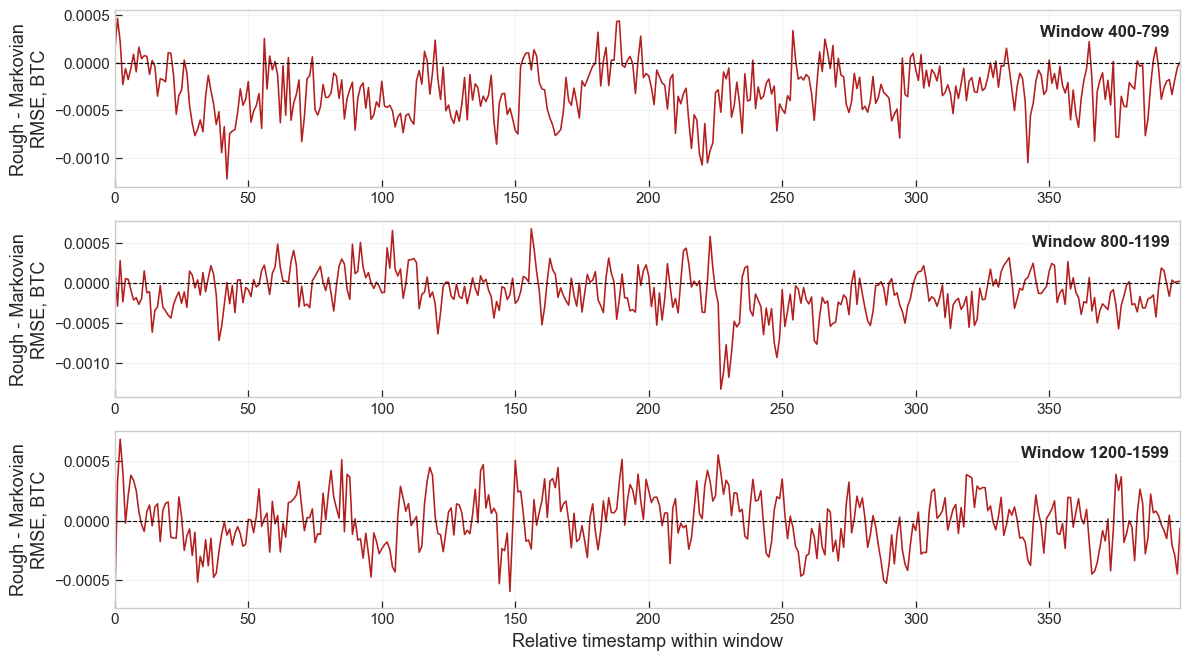

In [22]:
fig, axes = plt.subplots(len(WINDOW_ORDER), 1, figsize=(12, 2.2 * len(WINDOW_ORDER)), sharex=False)
if len(WINDOW_ORDER) == 1:
    axes = [axes]

for ax, window in zip(axes, WINDOW_ORDER):
    d = price_delta_time[price_delta_time["window"] == window].sort_values("t_index")
    if d.empty:
        ax.set_visible(False)
        continue

    x = np.arange(len(d))
    ax.plot(x, d["delta_rmse"], color="#b41f1f", linewidth=1.15)
    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.text(
        0.99,
        0.92,
        f"Window {WINDOW_LABELS.get(window, window)}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12,
        fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
    )
    ax.set_xlim(0, max(len(d) - 1, 1))
    ax.set_ylabel("Rough - Markovian\nRMSE, BTC", fontsize=13)
    ax.tick_params(axis="both", which="major", direction="in", labelsize=11, length=5, width=0.9)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Relative timestamp within window", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nonoverlap_eval_price_rmse_difference.png", dpi=200, bbox_inches="tight")
plt.show()

## Exported Files

Derived tables are written to `outputs/nonoverlap_q160_eval300/_comparison/tables`. The two main figures are written to `outputs/nonoverlap_q160_eval300/_comparison/figures`.